# ResNet18 — Test Time Augmentation (TTA) et Calibration du Seuil

## Objectif
Ce notebook met en place une **inférence avancée** pour améliorer les performances du modèle.

Nous allons :

1. Charger le meilleur modèle entraîné
2. Appliquer **Test Time Augmentation (TTA)**
3. Calculer les probabilités sur le jeu de validation
4. Tester plusieurs **seuils de décision**
5. Choisir un seuil optimal selon plusieurs stratégies
6. Appliquer ce seuil au **jeu de test final**

Cette approche est **scientifique et reproductible** contrairement à un seuil arbitraire.

## Étape 1 — Rendre le package importable

Cette cellule permet au notebook d'accéder au dossier `src/` du projet.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)

Project root: /home/alouiyaz/projects/PINKCC/PINKCC_challenge_Cité_neutral_Minds


## Étape 2 — Imports

On importe les modules du projet.

In [2]:
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

from torch.utils.data import DataLoader, Subset

from pinkcc_ct_seg.data.dataset import BrainMRIDataset
from pinkcc_ct_seg.data.transforms import get_eval_transforms, get_tta_transforms
from pinkcc_ct_seg.data.split import make_train_val_split

from pinkcc_ct_seg.models.resnet18 import build_resnet18

from pinkcc_ct_seg.training.engine import predict_probabilities

from pinkcc_ct_seg.evaluation.tta import predict_probabilities_tta
from pinkcc_ct_seg.evaluation.thresholding import (
    scan_thresholds,
    select_threshold_by_best_f1,
    select_threshold_by_recall_constraint,
    apply_threshold
)

from pinkcc_ct_seg.utils import set_seed, get_device, load_checkpoint

print("Torch version:", torch.__version__)

Torch version: 2.10.0+cu128


## Étape 3 — Configuration

Définition des paramètres globaux.

In [3]:
set_seed(42)
device = get_device()

IMG_SIZE = 224
BATCH_SIZE = 32

DATA_DIR = PROJECT_ROOT / "data/raw/brain_mri/Training"
TEST_DIR = PROJECT_ROOT / "data/raw/brain_mri/Testing"

MODEL_PATH = PROJECT_ROOT / "models/best_resnet18_methodB_advanced.pt"

print("Device:", device)

Device: cpu


## Étape 4 — Chargement des datasets

In [4]:
eval_tfms = get_eval_transforms(img_size=IMG_SIZE)
tta_tfms = get_tta_transforms(img_size=IMG_SIZE)

full_dataset = BrainMRIDataset(DATA_DIR, transform=eval_tfms)

labels = [full_dataset.samples[i][1] for i in range(len(full_dataset))]

train_idx, val_idx = make_train_val_split(labels, val_size=0.2)

val_dataset = Subset(full_dataset, val_idx)

test_dataset = BrainMRIDataset(TEST_DIR, transform=eval_tfms)

print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Validation size: 574
Test size: 394


## Étape 5 — Charger le modèle

In [5]:
model = build_resnet18(num_classes=2, pretrained=False)

model = load_checkpoint(model, MODEL_PATH, map_location=device)

model = model.to(device)
model.eval()

print("Model loaded")

Model loaded


## Étape 6 — Probabilités sur validation (sans TTA)

In [6]:
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

y_val, probs_val = predict_probabilities(model, val_loader, device)

## Étape 7 — Probabilités avec TTA

Chaque image est prédite plusieurs fois avec différentes transformations.

In [7]:
y_val_tta, probs_val_tta = predict_probabilities_tta(
    model,
    full_dataset,
    device,
    tta_tfms
)

## Étape 8 — Recherche du seuil optimal

In [8]:
results = scan_thresholds(y_val_tta, probs_val_tta)

best_f1 = select_threshold_by_best_f1(results)

best_recall = select_threshold_by_recall_constraint(results, min_recall=0.9)

print("Best F1 threshold:", best_f1)
print("Best Recall threshold:", best_recall)

Best F1 threshold: {'threshold': 0.2, 'accuracy': 0.9905923344947736, 'precision': 0.9967532467532467, 'recall': 0.9923232323232323, 'f1': 0.9945333063373153}
Best Recall threshold: {'threshold': 0.2, 'accuracy': 0.9905923344947736, 'precision': 0.9967532467532467, 'recall': 0.9923232323232323, 'f1': 0.9945333063373153}


## Étape 9 — Visualisation des métriques

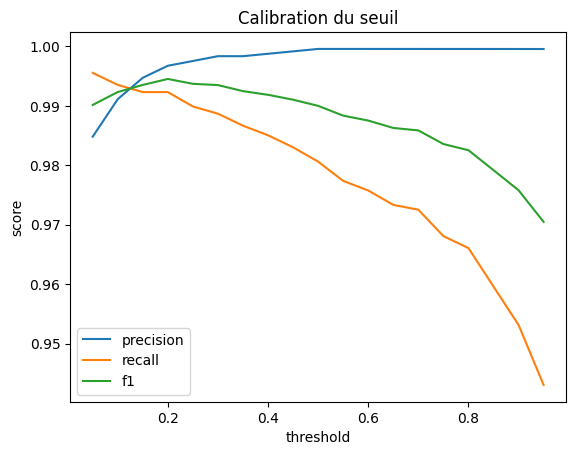

In [9]:
thresholds = [r['threshold'] for r in results]
precisions = [r['precision'] for r in results]
recalls = [r['recall'] for r in results]
f1 = [r['f1'] for r in results]

plt.plot(thresholds, precisions, label='precision')
plt.plot(thresholds, recalls, label='recall')
plt.plot(thresholds, f1, label='f1')

plt.legend()
plt.xlabel("threshold")
plt.ylabel("score")
plt.title("Calibration du seuil")
plt.show()

## Étape 10 — Application sur le jeu de test

In [10]:
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

y_test, probs_test = predict_probabilities(model, test_loader, device)

threshold = best_f1['threshold']

y_pred = apply_threshold(probs_test, threshold)

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.98      0.78       105
           1       0.99      0.80      0.89       289

    accuracy                           0.85       394
   macro avg       0.82      0.89      0.83       394
weighted avg       0.90      0.85      0.86       394

[[103   2]
 [ 57 232]]
